# 2D Overdamped model - Dialanine

In this tutorial we are going to infer Langevin model on simulation data of dialanine showcasing the analysis of 2D model.
The data are in the dialanine_trajectories.npz and contain 5 trajectories of equilibrium simulation of the dialanine with Gromacs. Files contain the values of the $\phi, \psi$ dihedrals angles.

In [1]:
import numpy as np
import folie as fl

data = fl.Trajectories(dt=0.2) 
trjs = np.load("dialanine_trajectories.npz")  # Values in radians, convert evrything into degree


# Convert to degree and also concatenate all values for histogram
# Offset to center the plot
phi_offset=60
psi_offset=-90
phi_all = []
psi_all=[]
for arr in trjs.values():
    phi_dat = (((np.rad2deg(arr[:, 0]) + 180) + phi_offset) % 360) - 180
    psi_dat = (((np.rad2deg(arr[:, 1]) + 180) + psi_offset) % 360) - 180
    phi_all=np.concatenate([phi_all,phi_dat])
    psi_all=np.concatenate([psi_all,psi_dat])
    data.append(np.column_stack([phi_dat,psi_dat]))
    
print(data) #Let's check what we have

Trajectory of length 100001 and dimension 2.
Trajectory of length 100001 and dimension 2.
Trajectory of length 100001 and dimension 2.
Trajectory of length 100001 and dimension 2.
Trajectory of length 100001 and dimension 2.



Let's looks at the Ramachandran plot of the trajectories

Text(0, 0.5, '$\\psi$')

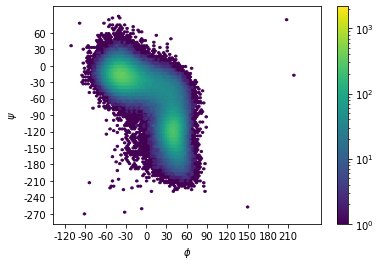

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.hexbin(
    phi_all,
    psi_all,
    extent=[-180, 180, -180, 180],
    bins=360,
    norm=LogNorm(),
)
plt.colorbar()

phi_s, phi_e = -180 + phi_offset, 180 + phi_offset
psi_s, psi_e = -180 + psi_offset, 180 + psi_offset
plt.xticks(np.arange(-180, 180, 30), np.arange(phi_s, phi_e, 30))
plt.yticks(np.arange(-180, 180, 30), np.arange(psi_s, psi_e, 30))

plt.xlabel("$\phi$")
plt.ylabel("$\psi$")

Let's use a complex spatial variation by using finite element basis.

In [8]:
import skfem
from folie.domains._mesh_utils import density_based_mesh
X=np.column_stack([phi_all, psi_all])
pts, tri = density_based_mesh(X, bins=50, Ninit_vertices=100, N_min=20, min_scale=0.2)
mesh = skfem.MeshTri(pts.T, tri.T)
domain = fl.MeshedDomain(mesh)

count =  0 N =  230 displacement =  7.773493503020898
count =  200 N =  230 displacement =  0.07192650783557716


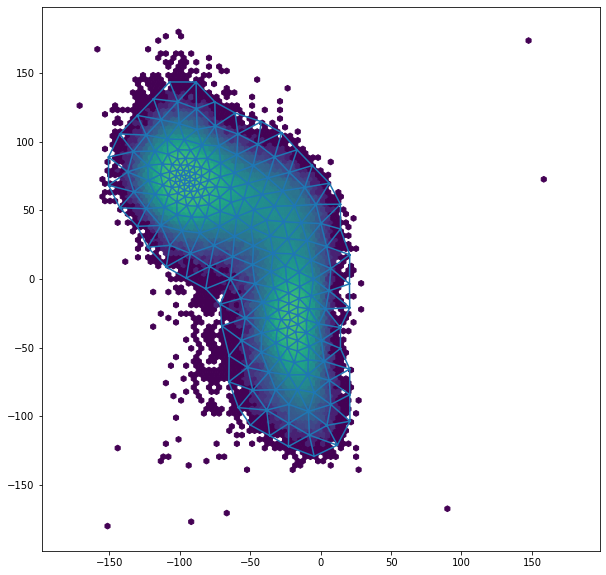

In [ ]:
# Plot the obtained mesh against the density of points in the space

fig, ax = plt.subplots(1, 1, figsize= (10,10))

ax.hexbin(
    phi_all,
    psi_all,
    extent=[-180, 180, -180, 180],
    bins=360,
    norm=LogNorm(),
)

ax.triplot(pts[:,0], pts[:,1], tri)


In [ ]:
# Now run the estimation
fun = fl.functions.FiniteElement(domain=domain, element=skfem.ElementTriP2())
model = fl.models.Overdamped(fun, dim=2)
estimator = fl.KramersMoyalEstimator(model)
model = estimator.fit_fetch(data)

We can then plot the force and diffusion profile

(230, 2)


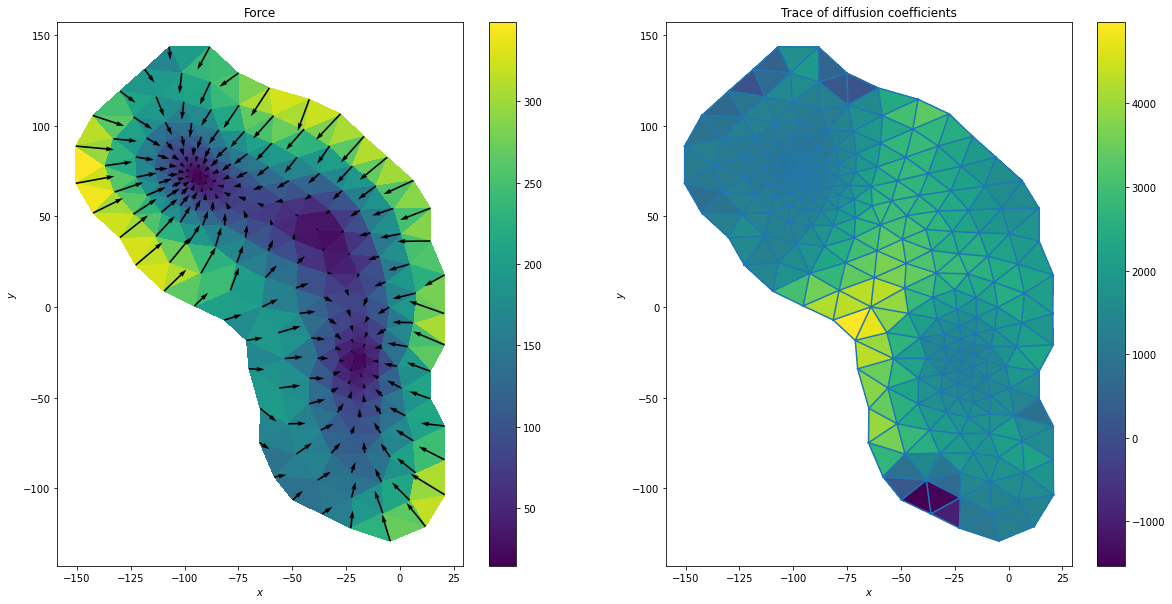

In [18]:
import matplotlib.pyplot as plt

forces= model.pos_drift(pts)
print(forces.shape)
fig, ax = plt.subplots(1, 2, figsize= (20,10))
# Force plot
ax[0].set_title("Force")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].grid()

force_mag = np.linalg.norm(forces, axis=1)
cset0=ax[0].tripcolor(pts[:,0],pts[:,1],force_mag, triangles= tri)
ax[0].quiver(pts[:,0],pts[:,1],forces[:,0], forces[:,1])
fig.colorbar(cset0, ax=ax[0])

ax[1].set_title("Trace of diffusion coefficients")
ax[1].set_xlabel("$x$")
ax[1].set_ylabel("$y$")
diff= model.diffusion(pts)

diff_mag = np.linalg.trace(diff)
cset1 =ax[1].tripcolor(pts[:,0],pts[:,1],diff_mag, triangles= tri)
ax[1].triplot(pts[:,0], pts[:,1], tri)
fig.colorbar(cset1, ax=ax[1])

But also obtain the free energy profile

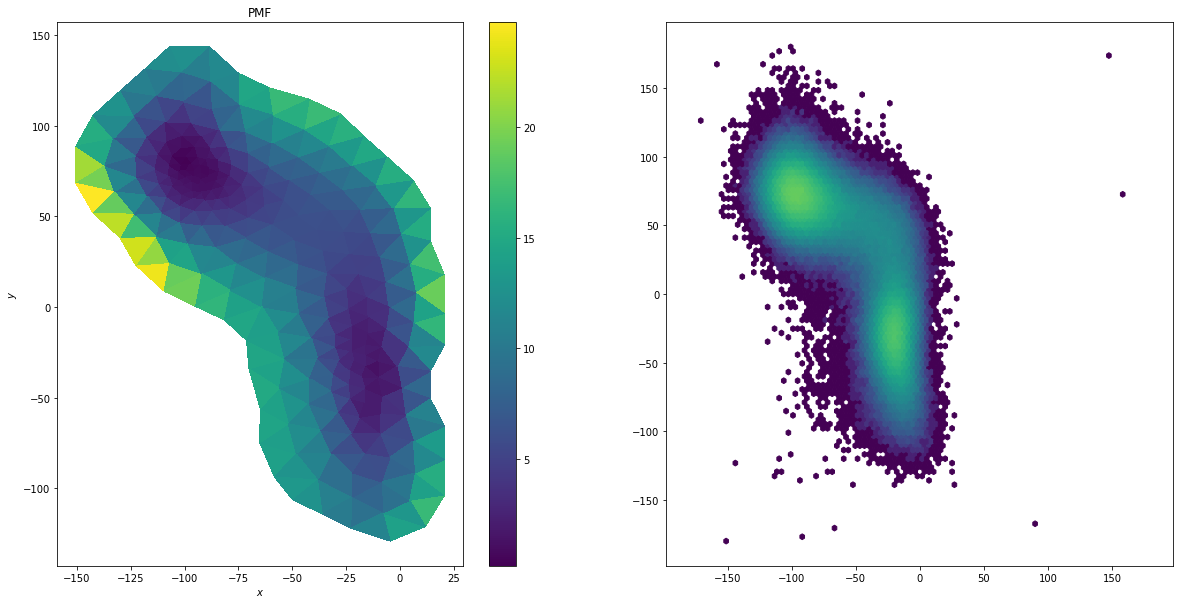

In [ ]:
basis = skfem.CellBasis(mesh, skfem.ElementTriP1())
Vpmf = fl.analysis.free_energy_profile(model, basis, x= pts)
fig, ax = plt.subplots(1, 2,  figsize= (20,10))
# Diffusion plot
ax[0].set_title("PMF")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
cset0=ax[0].tripcolor(pts[:,0],pts[:,1],Vpmf- np.min(Vpmf), triangles= tri)
fig.colorbar(cset0, ax=ax[0])

# To compare, plot again the log density
ax[1].hexbin(
    phi_all,
    psi_all,
    extent=[-180, 180, -180, 180],
    bins=360,
    norm=LogNorm(),
)


The next step is to compute the rate to pass from one state to the other one. This can be done here from an eigenvalues decomposition of the generator.

In [ ]:
xfa_to_unfold,mfpt_to_unfold = fl.analysis.mfpt_1d(model, 30, [-15,40], Npoints=500)
xfa_to_fold,mfpt_to_fold = fl.analysis.mfpt_1d(model, 0, [-15,40], Npoints=500)
fig, ax = plt.subplots(1, 1)
ax.set_title("MFPT")
ax.grid()
ax.set_xlabel("$x$")
ax.set_ylabel("$MFPT(x)$")
ax.plot(xfa_to_unfold, mfpt_to_unfold, label='unfolding')
ax.plot(xfa_to_fold,mfpt_to_fold, label='folding')
plt.legend()

# Compare it to ground truth

## Using transition path sampling

The trajectories used previously were equilibrium trajectories, so the analysis by mean of Langevin equation does not bring a lot of insight, let's now start from trajectories of transition path sampling of the same system. We use the protocol described at http://openpathsampling.org/latest/examples/AD_tps.html to obtain the trajectories.